In [6]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

raw = yf.download("SPY", start="2025-01-01", end="2026-01-01")
data = raw.droplevel("Ticker", axis=1)
data['daily_return'] = data['Close'].pct_change()

mu = data['daily_return'].mean()
sigma = data['daily_return'].std()

print(f"Daily mean return: {mu:.4%}")
print(f"Daily Volatility: {sigma:.4%}")

[*********************100%***********************]  1 of 1 completed

Daily mean return: 0.0740%
Daily Volatility: 1.2299%


In [41]:
np.random.seed(42)
S0 = data['Close'].iloc [-1] #last known SPY price
n_days = 252 # one year forward

# Generate 252 random daily returns
random_returns = np.random.normal(mu, sigma, n_days)

# Build price path
price_path = [S0] # Create a New List

for r in random_returns:
    price_path.append(price_path[-1] * (1 + r))

price_path = np.array(price_path)
print(price_path.shape)

print(f"Start price: ${price_path[0]:.2f}")
print(f"End price: ${price_path[-1]:.2f}")

(253,)
Start price: $680.06
End price: $795.66


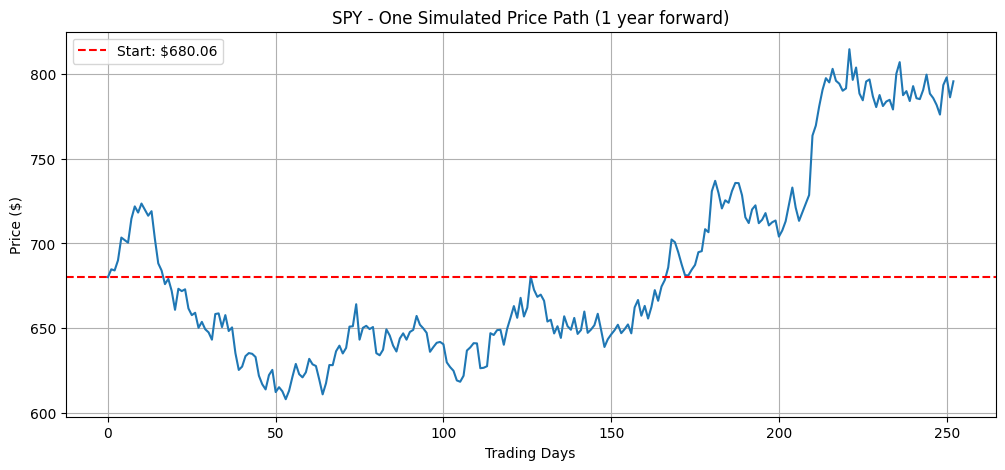

In [18]:
plt.figure(figsize=(12,5))
plt.plot(price_path)
plt.title("SPY - One Simulated Price Path (1 year forward)")
plt.xlabel("Trading Days")
plt.ylabel("Price ($)")
plt.axhline(y=S0, color='r', linestyle='--', label=f'Start: ${S0:.2f}')
plt.legend()
plt.grid(True)
plt.show()

In [33]:
np.random.seed(42)
n_simulations = 1000
n_days = 252

all_paths = []

for i in range(n_simulations):
    random_returns = np.random.normal(mu, sigma, n_days)
    path = [S0]
    for r in random_returns:
        path.append(path[-1] * (1 + r))
    all_paths.append(path)

all_paths = np.array(all_paths) #Important to convert numpy array (Optimization)

print(f"Shape: {all_paths.shape}")
print(f"First path final price: ${all_paths[0, -1]:.2f}")
print(f"Last path final price: ${all_paths[-1, -1]:.2f}")

Shape: (1000, 253)
First path final price: $795.66
Last path final price: $1056.91


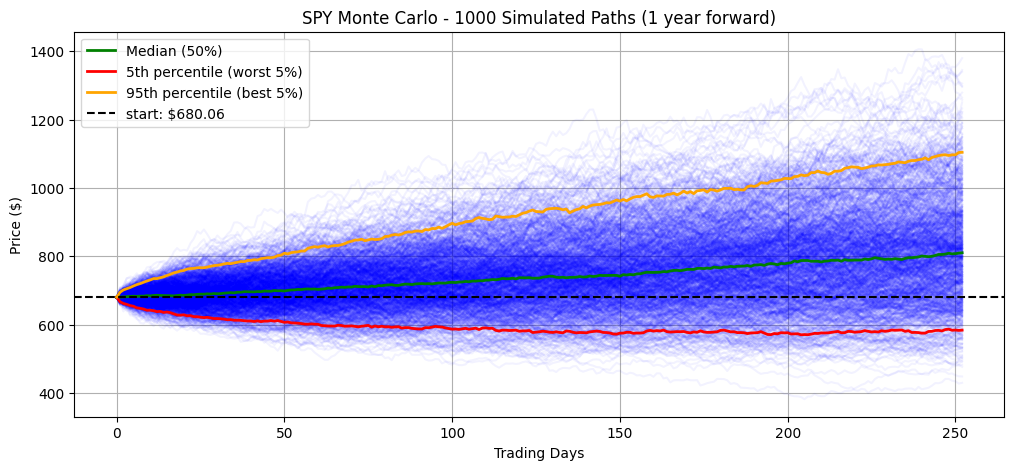

In [36]:
plt.figure(figsize=(12,5))

#Transpose array -> Plot always draw no.lines base on [Row=x axis, Column=y axis]
plt.plot(all_paths.T, alpha=0.05, color='blue') #[1000, 253] 253 lines -> [253, 1000] 1000 lines

#use plot instead of axhline -> Not a flat line
#percentile - sorting ascending order + pick accordingly
plt.plot(np.percentile(all_paths, 50, axis=0),
         color='green', linewidth=2, label='Median (50%)')
plt.plot(np.percentile(all_paths, 5, axis=0),
         color='red', linewidth=2, label='5th percentile (worst 5%)')
plt.plot(np.percentile(all_paths, 95, axis=0),
         color='orange', linewidth=2, label='95th percentile (best 5%)')

plt.axhline(y=S0, color='black', linestyle='--', label=f'start: ${S0:.2f}')
plt.title("SPY Monte Carlo - 1000 Simulated Paths (1 year forward)")
plt.xlabel("Trading Days")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True)
plt.show()

In [37]:
final_prices = all_paths[:, -1]
prob_profit = (final_prices > S0).mean()
print(f"Probability of profit after 1 year: {prob_profit:.1%}")
print(f"Median final price: ${np.median(final_prices):.2f}")
print(f"5th percentile: ${np.percentile(final_prices, 5):.2f}")
print(f"95th percentile: ${np.percentile(final_prices, 95):.2f}")

Probability of profit after 1 year: 78.8%
Median final price: $810.03
5th percentile: $583.53
95th percentile: $1104.25
